# Exploratory Data Analysis (EDA)

Exploratory data analysis (EDA) is conducted to understand the statistical and spatial characteristics of the Social Vulnerability Index (SVI) dataset prior to model development. Because the objective of this study is to predict county-level SVI values using both tabular and spatial graph-based models, it is important to first examine the distributions, relationships, and potential structural patterns present in the data. EDA helps identify issues such as skewed feature distributions, multicollinearity among predictors, and spatial variability across regions. These insights guide preprocessing decisions including feature transformations, normalization, and the design of the modeling pipeline.

A summary of the processed datasets used for EDA and modeling is presented in @tbl-svi-data-summary. This summary includes the feature matrix (X), target variables (y), and the spatial geometry dataset (geo_df) used for constructing the geographic graph.

The dataset contains 3,144 counties, with 16 EP_ feature variables* used as predictors and four SVI theme targets. All datasets contain consistent data types and no missing values, ensuring that the data are suitable for training both tabular and graph-based models.

The analysis is organized into two main components: target variable exploration and feature matrix exploration.

In [103]:
#| output: false

import sys
from pathlib import Path

# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: c:\Users\joetn\CS273P_MachineLearning_Final_Project


In [142]:
from src.eda import (
    evaluate_kmeans_k,
    choose_k_gap_rule,
    fit_kmeans,
    pca_project,
    plot_k_diagnostics,
    plot_clusters_pca,
)

import json
import libpysal
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans

from statsmodels.stats.outliers_influence import variance_inflation_factor


# Set plt plotting configs
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,
    "legend.frameon": True,
    "legend.borderpad": 0.3
})

In [105]:
#| output: false

# Data directories
DATA_DIR = Path("../data/raw")
SVI_PATH = DATA_DIR / "SVI_2022_US_county.csv"
SHAPE_PATH = DATA_DIR / "tl_2022_us_county/tl_2022_us_county.shp"

# Load svi.csv
svi = pd.read_csv(SVI_PATH)

# Load county lines
counties = gpd.read_file(SHAPE_PATH)

In [106]:
#| output: false

print(svi.shape)
svi.head()

(3144, 158)


,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,1,Alabama,AL,1001,Autauga County,1001,"Autauga County, Alabama",594.454786,58761,0,...,1.1,0.4,0.1,0.1,0.0,0.1,3.3,1.0,0.2,0.3
1,1,Alabama,AL,1003,Baldwin County,1003,"Baldwin County, Alabama",1589.861817,233420,0,...,0.9,0.1,0.2,0.1,0.0,0.1,3.1,0.4,0.4,0.3
2,1,Alabama,AL,1005,Barbour County,1005,"Barbour County, Alabama",885.007619,24877,0,...,0.5,0.1,0.3,0.1,0.0,0.1,1.8,0.7,1.2,0.8
3,1,Alabama,AL,1007,Bibb County,1007,"Bibb County, Alabama",622.469286,22251,0,...,0.3,0.4,0.1,0.1,0.0,0.2,1.7,1.0,0.1,0.1
4,1,Alabama,AL,1009,Blount County,1009,"Blount County, Alabama",644.890376,59077,0,...,0.2,0.2,0.1,0.1,0.2,0.2,2.8,0.7,0.1,0.1


In [107]:
#| output: false

print(counties.shape)
counties.head()

(3235, 18)


,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,Cuming,Cuming County,06,H1,G4020,None,None,None,A,1477644346,10691216,+41.9158651,-096.7885168,"POLYGON ((-96.55516 41.91587, -96.55515 41.914..."
1,53,069,01513275,53069,Wahkiakum,Wahkiakum County,06,H1,G4020,None,None,None,A,680980770,61564427,+46.2946377,-123.4244583,"POLYGON ((-123.72755 46.2645, -123.72756 46.26..."
2,35,011,00933054,35011,De Baca,De Baca County,06,H1,G4020,None,None,None,A,6016818946,29090018,+34.3592729,-104.3686961,"POLYGON ((-104.89337 34.08894, -104.89337 34.0..."
3,31,109,00835876,31109,Lancaster,Lancaster County,06,H1,G4020,None,None,None,A,2169272978,22847034,+40.7835474,-096.6886584,"POLYGON ((-96.68493 40.5233, -96.69219 40.5231..."
4,31,129,00835886,31129,Nuckolls,Nuckolls County,06,H1,G4020,None,None,None,A,1489645185,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.2737 40.1184, -98.27374 40.1224,..."


In [108]:
# Standardize FIPS in svi
svi["FIPS"] = svi["FIPS"].astype(str).str.zfill(5)

# Extract FIPS as ID and required geometry
counties["FIPS"] = (counties["STATEFP"].astype(str) + counties["COUNTYFP"].astype(str)).str.zfill(5)
counties_c = counties[["FIPS", "geometry"]]

# Merge on FIPS
geo_df = svi.merge(
    counties_c[["FIPS", "geometry"]],
    on="FIPS",
    how="inner"
).sort_values("FIPS").reset_index(drop=True)

# Convert back to gpd
geo_df = gpd.GeoDataFrame(geo_df, geometry="geometry")

In [109]:
# Define SVI theme targets
target_cols = [
    "RPL_THEME1",
    "RPL_THEME2",
    "RPL_THEME3",
    "RPL_THEME4",
]

# Define overall target
overall_target = ["RPL_THEMES"]

# Define percentage indicators (EP_*)
feature_cols_ep = [
    # Theme 1:
    "EP_POV150",
    "EP_UNEMP",
    "EP_HBURD",   
    "EP_NOHSDP",
    "EP_UNINSUR",
    
    # Theme 2:
    "EP_AGE65",
    "EP_AGE17",
    "EP_DISABL",
    "EP_SNGPNT",
    "EP_LIMENG",
    
    # Theme 3:
    "EP_MINRTY",
    
    # Theme 4:
    "EP_MUNIT",
    "EP_MOBILE",
    "EP_CROWD",
    "EP_NOVEH",
    "EP_GROUPQ"
]

# Define feature matrix (X) using percentage indicators
X = svi[feature_cols_ep].copy()

# Define target matrix (y) using target themes
y = svi[target_cols].copy()

In [110]:
#| label: tbl-svi-data-summary
#| tbl-cap: "Summary of the modeling datasets used in this study. The feature matrix (X) contains 3,144 U.S. counties and 15 socioeconomic and demographic indicators derived from the CDC Social Vulnerability Index (SVI) dataset. The target matrix (y) contains the four SVI theme percentile rankings (RPL_THEME1–RPL_THEME4), enabling a multi-task prediction framework. The spatial geometry dataset (geo_df) provides county polygon boundaries used to construct the spatial adjacency graph for Graph Neural Network modeling. No missing values were observed in the feature or target matrices."
#| output: false

dataset_summary = pd.DataFrame({
    "dataset": ["X (features)", "y (targets)", "geo_df (geometry)"],
    
    "dimensions": [
        f"{X.shape[0]} x {X.shape[1]}",
        f"{y.shape[0]} x {y.shape[1]}",
        f"{geo_df.shape[0]} x {geo_df.shape[1]}"
    ],
    
    "dtype": [
        ", ".join(X.dtypes.unique().astype(str)),
        ", ".join(y.dtypes.unique().astype(str)),
        ", ".join(geo_df.dtypes.unique().astype(str))
    ],
    
    "missing_values": [
        X.isna().sum().sum(),
        y.isna().sum().sum(),
        geo_df.isna().sum().sum()
    ],
    
    "missing_rate": [
        X.isna().sum().sum() / X.size,
        y.isna().sum().sum() / y.size,
        geo_df.isna().sum().sum() / geo_df.size
    ]
})

display(dataset_summary.style.hide(axis="index"))

dataset,dimensions,dtype,missing_values,missing_rate
X (features),3144 x 16,float64,0,0.000000
y (targets),3144 x 4,float64,0,0.000000
geo_df (geometry),3144 x 159,"int64, str, float64, geometry",0,0.000000


## Target Variables

The target variables for this study are the SVI theme percentile rankings (RPL_THEME*), which represent county-level relative vulnerability across four thematic dimensions: socioeconomic status, household characteristics, racial and ethnic minority status, and housing type and transportation. Because these values are defined as percentile rankings ranging from 0 to 1, they measure how vulnerable a county is relative to other counties nationwide rather than providing an absolute measure of vulnerability. Understanding the statistical and geographic properties of these targets is important for interpreting model predictions and assessing potential relationships between vulnerability dimensions.

### Distribution of SVI Themes

The distribution of the SVI theme variables is shown in @fig-svi-y-dist. Across all themes, the distributions appear approximately uniform across the percentile range, which is expected given that the values represent percentile rankings computed from national comparisons. Each theme spans nearly the full range from 0 to 1 with relatively even frequency across bins. This indicates that counties are distributed across the entire vulnerability spectrum rather than concentrated at a particular percentile level.

Theme 3 (Minority Status and Language) exhibits slightly more variability in the lower percentiles relative to the other themes, suggesting that minority population distributions may be more uneven across counties. However, overall the target variables appear well-balanced, which is advantageous for regression modeling because it reduces the likelihood that models will be dominated by a narrow subset of values.

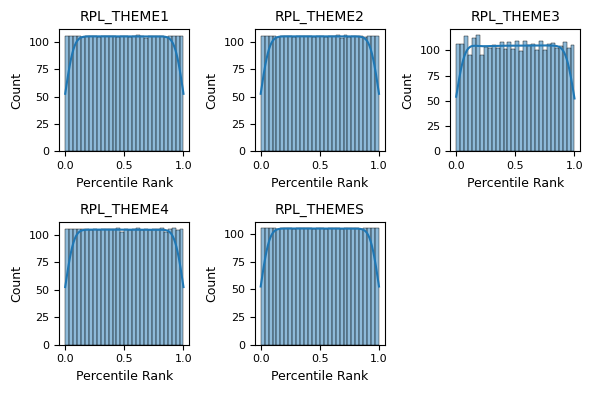

In [111]:
#| label: fig-svi-y-dist
#| fig-cap: "Distribution of county-level Social Vulnerability Index (SVI) percentile rankings across 3,144 U.S. counties. Each subplot shows the distribution of vulnerability scores for the four SVI themes and the overall SVI ranking (RPL_THEMES). Because these variables are defined as national percentile ranks, their distributions appear approximately uniform across counties, indicating that the targets are well-scaled within the [0,1] interval for regression-based multi-task modeling."

# Combine targets with overall SVI theme (RPL_THEMES)
plot_df = y.copy()
plot_df["RPL_THEMES"] = svi[overall_target]

themes = target_cols + overall_target

fig, axes = plt.subplots(2, 3, figsize=(6, 4))
axes = axes.flatten()

# Plot distributions
for i, theme in enumerate(themes):
    sns.histplot(
        plot_df[theme],
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(theme)
    axes[i].set_xlabel("Percentile Rank")
    axes[i].set_ylabel("Count")

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

### Correlation Between Themes

The correlation matrix shown in @fig-svi-y-corr reveals moderate positive relationships among most vulnerability themes. Correlations generally range between approximately 0.27 and 0.58, indicating that while the themes capture related aspects of vulnerability, they are not redundant representations of the same underlying construct.

The strongest relationships occur between:

Theme 1 (Socioeconomic Status) and Theme 2 (Household Characteristics) (~0.58)

Theme 1 and Theme 4 (Housing & Transportation) (~0.57)

These correlations are consistent with expectations, as economic hardship is often associated with housing instability and household vulnerability. In contrast, the weakest relationship occurs between Theme 2 and Theme 4 (~0.27), suggesting that household demographic factors and housing structure characteristics may represent more distinct dimensions of vulnerability.

Overall, the correlation structure indicates that the themes share some common socioeconomic signal while still capturing distinct vulnerability patterns, supporting the use of multi-target prediction rather than collapsing them into a single aggregated score (RPL_THEMES).

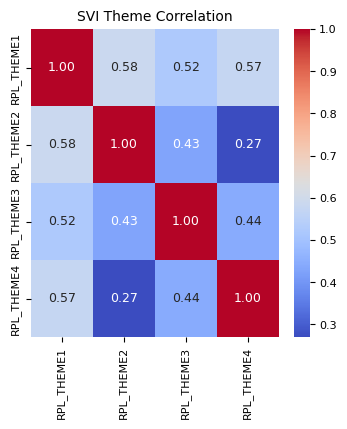

In [112]:
#| label: fig-svi-y-corr
#| fig-cap: "Correlation matrix of the four Social Vulnerability Index (SVI) theme percentile rankings across 3,144 U.S. counties. Moderate positive correlations are observed between several vulnerability dimensions, including socioeconomic status with household composition (r = 0.58) and housing/transportation (r = 0.57). Minority status and language vulnerability also shows moderate associations with other themes (r ≈ 0.43–0.52), while household composition exhibits weaker relationships with minority status (r = 0.43) and housing/transportation (r = 0.27). These relationships suggest that while themes capture related aspects of vulnerability, they remain distinct dimensions, motivating a multi-task learning approach for jointly predicting SVI themes."

# Compute correlation scores
corr = svi[target_cols].corr()

plt.figure(figsize=(4,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("SVI Theme Correlation")
plt.show()

### Pairwise Relationships

The pairplot visualization in @fig-svi-y-pairplot provides a more detailed view of the pairwise relationships between theme variables. The scatter plots show broadly diffuse clouds of points without strong nonlinear patterns, indicating that relationships between themes are generally monotonic but not tightly constrained. This observation aligns with the moderate correlations observed in the correlation matrix.

Because the targets are percentile rankings, the distributions appear relatively uniform along each axis, producing rectangular scatter regions rather than strongly clustered patterns. This suggests that each theme captures partially independent variation across counties. From a modeling perspective, this indicates that learning relationships between input features and each theme will require capturing distinct socioeconomic mechanisms rather than relying on simple cross-theme dependencies.

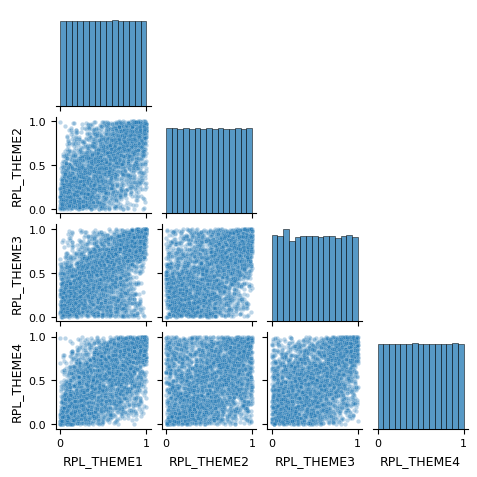

In [113]:
#| label: fig-svi-y-pairplot
#| fig-cap: "Pairwise relationships between the four Social Vulnerability Index (SVI) theme percentile rankings across 3,144 U.S. counties. Histograms along the diagonal show the approximately uniform distribution of percentile-based SVI theme scores, while scatter plots illustrate moderate positive associations between several vulnerability dimensions. These patterns indicate that counties experiencing one form of vulnerability often exhibit others, while still retaining distinct structural components."
sns.pairplot(
    svi[target_cols],
    corner=True,
    height=1.2,
    plot_kws={"alpha":0.3, "s":10}
)

### Geographic Distribution of Vulnerability

Spatial patterns of vulnerability are illustrated in @fig-svi-y-map-conus for the contiguous United States (CONUS) and in @fig-svi-y-map-oconus for Alaska and Hawaii (OCONUS). Several regional patterns are visible in the CONUS map. Counties in portions of the Southeastern United States, the Southwest, and parts of the Mississippi Delta tend to exhibit higher vulnerability scores, whereas many counties in the Upper Midwest and portions of the Northeast show relatively lower vulnerability. These geographic patterns reflect well-documented regional disparities in socioeconomic conditions, health outcomes, and infrastructure access.

The maps also reveal that vulnerability often exhibits regional clustering, where neighboring counties display similar vulnerability levels. This spatial clustering suggests that vulnerability is not randomly distributed across geographic space but instead reflects broader regional socioeconomic structures and demographic patterns.

The OCONUS map in @fig-svi-y-map-oconus highlights similar variability in Alaska and Hawaii. Alaska displays substantial heterogeneity across boroughs and census areas, while Hawaii generally exhibits moderate vulnerability levels across its counties. The absence of territorial data reflects dataset limitations rather than a lack of vulnerability patterns.

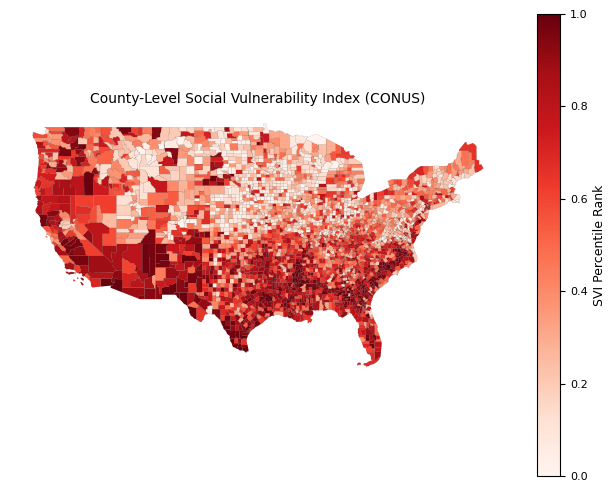

In [114]:
#| label: fig-svi-y-map-conus
#| fig-cap: "County-level distribution of the Social Vulnerability Index (SVI) across the contiguous United States (CONUS). Darker shades indicate higher vulnerability based on the CDC SVI percentile ranking (RPL_THEMES). The spatial clustering of vulnerability across neighboring counties suggests that geographic structure may provide useful information for predictive modeling, motivating the use of Graph Neural Networks."

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Remove Alaska, Hawaii, and territories
conus = geo_df[~geo_df["FIPS"].str.startswith(("02", "15", "60", "66", "69", "72", "78"))]

conus.plot(
    column="RPL_THEMES",
    cmap="Reds",
    linewidth=0.05,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "SVI Percentile Rank"},
    ax=ax
)

ax.set_title("County-Level Social Vulnerability Index (CONUS)")
ax.axis("off")

plt.show()

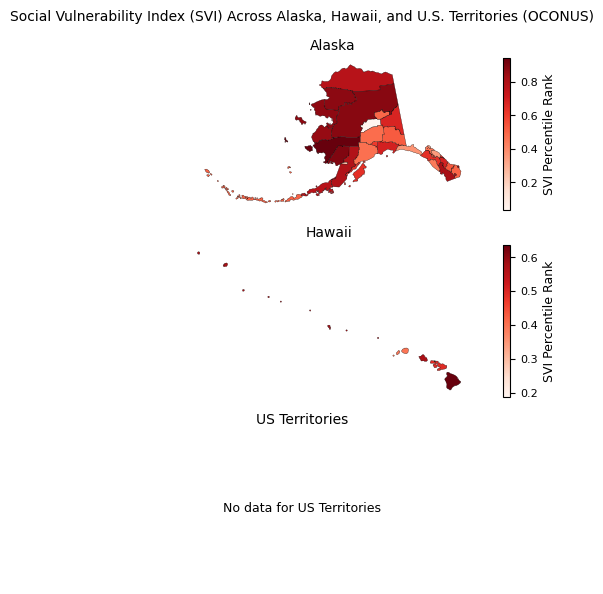

In [115]:
#| label: fig-svi-y-map-oconus
#| fig-cap: "County-level Social Vulnerability Index (SVI) percentile rankings for Alaska, Hawaii, and U.S. territories. These OCONUS regions are visualized separately from the CONUS to avoid geographic scaling distortions caused by their large spatial separation. Darker shades indicate higher social vulnerability based on the CDC SVI overall percentile ranking (RPL_THEMES). Missing SVI data for US territories."

# Define Alaska, Hawaii, and territories
ak = geo_df[geo_df["FIPS"].str.startswith("02")]
hi = geo_df[geo_df["FIPS"].str.startswith("15")]
territories = geo_df[geo_df["FIPS"].str.startswith(("60", "66", "69", "72", "78"))]

# Convert to specific CRS for reprojection
ak_proj = ak.to_crs("EPSG:3338")   
hi_proj = hi.to_crs("EPSG:3759")   
territories_proj = territories.to_crs("EPSG:3857")

fig, axes = plt.subplots(3, 1, figsize=(6, 6))

fig.suptitle(
    "Social Vulnerability Index (SVI) Across Alaska, Hawaii, and U.S. Territories (OCONUS)",
    fontsize=10
)

oconus_datasets = [
    (ak_proj, "Alaska"),
    (hi_proj, "Hawaii"),
    (territories_proj, "US Territories")
]

for ax, (data, title) in zip(axes, oconus_datasets):
    if data.empty:
        ax.text(0.5, 0.5, f"No data for {title}", ha="center", va="center")
        ax.set_title(title)
        ax.axis("off")
        continue

    data.plot(
        column="RPL_THEMES",
        cmap="Reds",
        linewidth=0.2,
        edgecolor="black",
        legend=True,
        legend_kwds={"label": "SVI Percentile Rank"},
        ax=ax
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Implications for Modeling

Several observations from the target variable analysis inform the subsequent modeling approach. First, the approximately uniform distributions of the theme percentile rankings suggest that the regression targets are well-scaled and balanced, which simplifies training for neural network models. Second, the moderate correlations between themes indicate that vulnerability dimensions share some common structure but remain distinct enough to justify modeling them as separate targets. Finally, the clear spatial clustering visible in the geographic maps suggests that neighboring counties may share vulnerability characteristics, motivating the use of graph-based models that explicitly incorporate spatial relationships between counties.

These findings support the use of graph neural networks and graph convolutional networks in later sections of the analysis, where spatial adjacency between counties is incorporated into the modeling framework.

## Feature Matrix

The predictor variables used in this study are the EP_ indicators, which represent estimated percentages of populations experiencing conditions associated with social vulnerability. These indicators capture multiple dimensions of vulnerability including socioeconomic hardship, demographic dependency, minority status, housing conditions, and transportation access. Because the variables are expressed as population percentages rather than raw counts, they provide normalized measures that allow counties with different population sizes to be compared on a consistent scale.

To understand the statistical structure of the feature space and guide preprocessing decisions, several analyses are conducted, including distribution analysis, moment diagnostics, transformation evaluation, correlation analysis, and multicollinearity assessment.

In [116]:
# Short titles based on CDC SVI documentation
feature_titles = {
    # Theme 1: Socioeconomic
    "EP_POV150": "≤150% Poverty (%)",
    "EP_UNEMP": "Unemployment (%)",
    "EP_HBURD": "Housing Cost Burden (%)",
    "EP_NOHSDP": "No High School Diploma (%)",
    "EP_UNINSUR": "Uninsured (%)",

    # Theme 2: Household Composition
    "EP_AGE65": "Age 65+ (%)",
    "EP_AGE17": "Age ≤17 (%)",
    "EP_DISABL": "Disability (%)",
    "EP_SNGPNT": "Single-Parent HH (%)",
    "EP_LIMENG": "Limited English (%)",

    # Theme 3: Minority & Language
    "EP_MINRTY": "Minority (%)",
    
    # Theme 4: Housing & Transportation
    "EP_MUNIT": "Multi-Unit Housing (%)",
    "EP_MOBILE": "Mobile Homes (%)",
    "EP_CROWD": "Crowded Housing (%)",
    "EP_NOVEH": "No Vehicle (%)",
    "EP_GROUPQ": "Group Quarters (%)"
}

# Define cols and n for plotting
cols = X.columns
n_cols = len(cols)


### Feature Distributions

The distributions of the EP_* feature variables across counties are shown in @fig-svi-x-dist. Many indicators exhibit right-skewed distributions, where a large number of counties have relatively low values while a smaller number of counties exhibit substantially higher vulnerability levels. This pattern is particularly visible for variables such as crowded housing, group quarters, multi-unit housing, and limited English proficiency, where the majority of counties report low percentages but a subset show much higher concentrations.

Some demographic variables such as age distributions and disability rates appear more approximately symmetric, indicating that these characteristics vary more evenly across counties. In contrast, socioeconomic stress indicators such as poverty, unemployment, and uninsured populations show moderate skewness, reflecting known regional disparities in economic conditions across the United States.

These distribution patterns suggest that certain variables may benefit from transformation in order to stabilize variance and improve numerical behavior during model training.

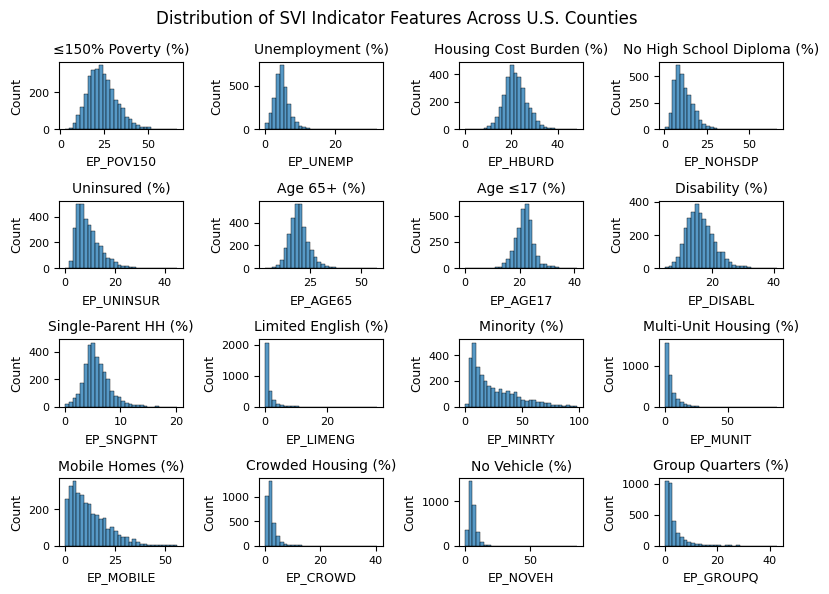

In [117]:
#| label: fig-svi-x-dist
#| fig-cap: "Empirical distributions of county-level SVI indicator variables used as model input features. Each subplot shows the frequency distribution of a socioeconomic, demographic, or housing indicator across U.S. counties. Several variables exhibit pronounced right-skew and heavy tails, particularly housing and language-related indicators, motivating subsequent distribution diagnostics and selective log transformation."

fig, axes = plt.subplots(4, 4, figsize=(8, 6))
axes = axes.flatten()

fig.suptitle(
    "Distribution of SVI Indicator Features Across U.S. Counties",
    fontsize=12
)

for i, col in enumerate(cols):
    sns.histplot(X[col], bins=30, ax=axes[i])

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].set_title(feature_titles.get(col, col))

for j in range(n_cols, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Distribution Moments and Skewness

To quantify the observed distribution patterns, skewness and kurtosis statistics are computed for each feature, as shown in @fig-svi-moments. Several variables exhibit substantial positive skewness, particularly those associated with housing conditions and access to resources. For example, no vehicle access, crowded housing, and limited English proficiency display strong right-skewed distributions. High kurtosis values for some variables further indicate heavy-tailed behavior, where extreme observations occur more frequently than would be expected under a normal distribution.

These characteristics are common in socioeconomic datasets where certain vulnerability conditions are concentrated within specific geographic regions or demographic groups.

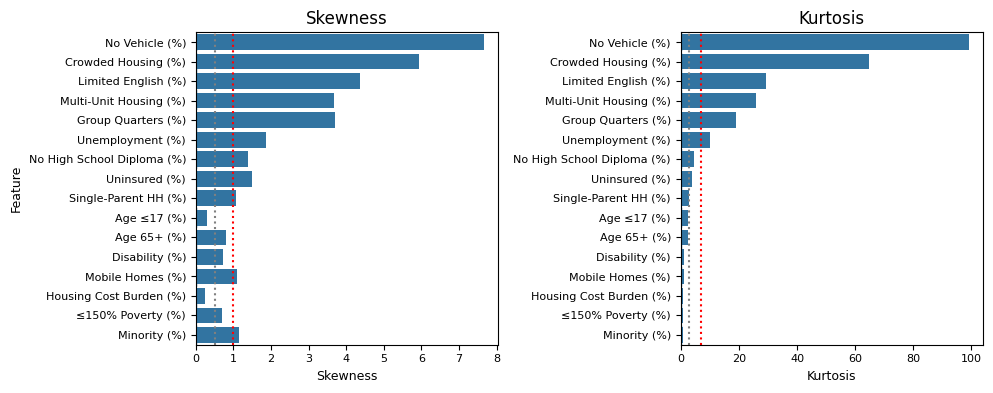

In [118]:
#| label: fig-svi-moments
#| fig-cap: "Skewness and kurtosis diagnostics for county-level SVI indicator variables. The left panel shows skewness (distribution asymmetry) and the right panel shows kurtosis (tail heaviness relative to a normal distribution). Vertical reference lines indicate commonly used thresholds for moderate and strong deviations from normality, highlighting substantial right-skew and heavy tails in several housing and demographic indicators."

# Compute distribution statistics
moments = pd.DataFrame({
    "Variable": X.columns,
    "Skewness": X.skew(),
    "Kurtosis": X.kurtosis()
})

# Map readable feature names
moments["Feature"] = moments["Variable"].map(feature_titles).fillna(moments["Variable"])

# Sort by kurtosis
moments = moments.sort_values("Kurtosis", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Skewness
sns.barplot(
    x="Skewness",
    y="Feature",
    data=moments,
    ax=axes[0],
    orient="h"
)

axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].axvline(0.5, linestyle=":", color="gray")
axes[0].axvline(1, linestyle=":", color="red")

axes[0].set_title("Skewness", fontsize=12)
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Feature")

# Kurtosis
sns.barplot(
    x="Kurtosis",
    y="Feature",
    data=moments,
    ax=axes[1],
    orient="h"
)

axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].axvline(3, linestyle=":", color="gray")
axes[1].axvline(7, linestyle=":", color="red")

axes[1].set_title("Kurtosis", fontsize=12)
axes[1].set_xlabel("Kurtosis")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Log Transformation Effects

To address skewness and heavy-tailed behavior, selected variables are transformed using logarithmic scaling. The effects of these transformations are summarized in @fig-svi-log-moments and illustrated visually in @fig-svi-x-log-dist.

After transformation, several features show reduced skewness and kurtosis, resulting in more symmetric distributions. Log scaling is particularly effective for features such as crowded housing, limited English proficiency, group quarters, mobile homes, multi-unit housing, and no vehicle access, where the original distributions exhibited strong right tails.

Reducing skewness improves numerical stability during model training and helps ensure that neural network optimization is not dominated by extreme values.

In [119]:
# Variables to log-transform
log_vars = [
    "EP_LIMENG",
    "EP_CROWD",
    "EP_GROUPQ",
    "EP_MOBILE",
    "EP_NOVEH",
    "EP_MUNIT"
]

# Copy original feature matrix
X_log = X.copy()

# Create log-transformed columns
for col in log_vars:
    X_log[f"{col}_LOG"] = np.log1p(X_log[col])

# Drop original versions
X_log = X_log.drop(columns=log_vars)

# Reorder columns for readability
X_log = X_log.reindex(sorted(X_log.columns), axis=1)

# Update feature title mapping
feature_titles_log = feature_titles.copy()
feature_titles_log.update({
    "EP_LIMENG_LOG": "Limited English (log)",
    "EP_CROWD_LOG": "Crowded Housing (log)",
    "EP_GROUPQ_LOG": "Group Quarters (log)",
    "EP_MOBILE_LOG": "Mobile Homes (log)",
    "EP_NOVEH_LOG": "No Vehicle (log)",
    "EP_MUNIT_LOG": "Multi-Unit Housing (log)"
})

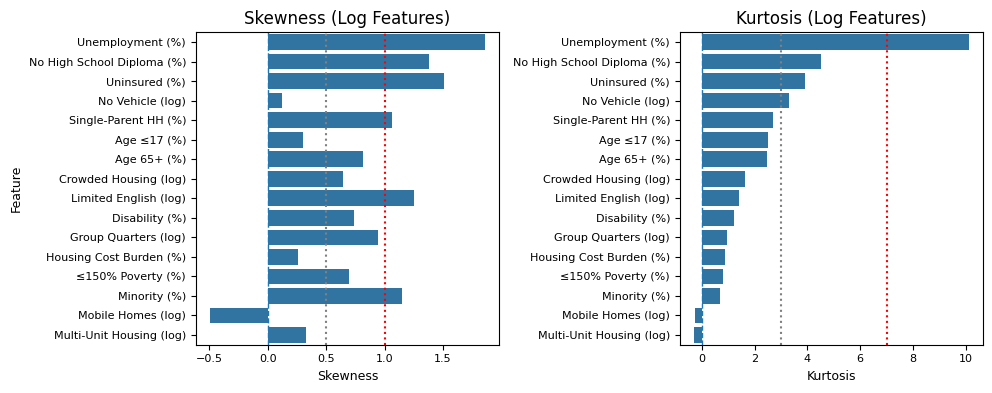

In [120]:
#| label: fig-svi-log-moments
#| fig-cap: "Skewness and kurtosis diagnostics for SVI indicators after selective log transformation using log(x+1). The transformation reduces strong right-skew and heavy-tailed behavior observed in several housing and language indicators. Vertical reference lines indicate common interpretation thresholds for skewness (|0.5| moderate, |1| strong) and kurtosis (3 moderate, 7 heavy-tailed), helping assess the extent to which the transformed variables approach more symmetric distributions."

moments_log = pd.DataFrame({
    "Variable": X_log.columns,
    "Skewness": X_log.skew(),
    "Kurtosis": X_log.kurtosis()
})

moments_log["Feature"] = moments_log["Variable"].map(feature_titles_log).fillna(moments_log["Variable"])

moments_log = moments_log.sort_values("Kurtosis", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Skewness
sns.barplot(
    x="Skewness",
    y="Feature",
    data=moments_log,
    ax=axes[0],
    orient="h"
)

axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].axvline(0.5, linestyle=":", color="gray")
axes[0].axvline(1, linestyle=":", color="red")

axes[0].set_title("Skewness (Log Features)", fontsize=12)
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Feature")

# Kurtosis
sns.barplot(
    x="Kurtosis",
    y="Feature",
    data=moments_log,
    ax=axes[1],
    orient="h"
)

axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].axvline(3, linestyle=":", color="gray")
axes[1].axvline(7, linestyle=":", color="red")

axes[1].set_title("Kurtosis (Log Features)", fontsize=12)
axes[1].set_xlabel("Kurtosis")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

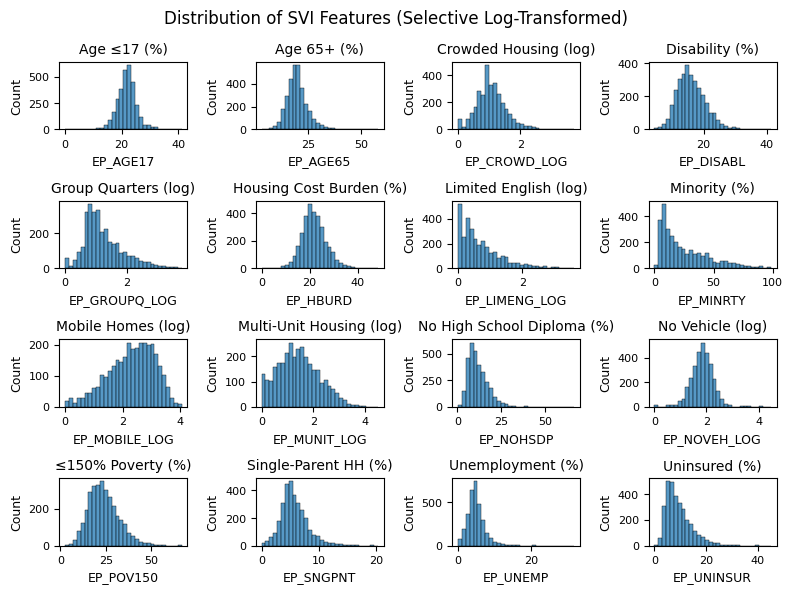

In [121]:
#| label: fig-svi-x-log-dist
#| fig-cap: "Distributions of the final SVI feature set after selective log transformation. Variables exhibiting strong right-skew were transformed using log(x+1), improving symmetry and reducing heavy-tailed behavior."

cols_log = X_log.columns
n_cols_log = len(cols_log)

fig, axes = plt.subplots(4, 4, figsize=(8, 6))
axes = axes.flatten()

fig.suptitle(
    "Distribution of SVI Features (Selective Log-Transformed)",
    fontsize=12
)

for i, col in enumerate(cols_log):
    sns.histplot(X_log[col], bins=30, ax=axes[i])

    axes[i].set_title(feature_titles_log.get(col,col))
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(n_cols_log, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Feature Correlation Structure

The correlation matrix shown in @fig-svi-corr illustrates relationships between the transformed feature variables. Several moderate correlations are observed, reflecting the fact that many vulnerability indicators capture related socioeconomic phenomena.

For example, poverty, unemployment, and lack of high school education tend to be positively correlated, consistent with well-documented relationships between education, employment, and economic hardship. Similarly, certain housing variables show associations with transportation access and minority population concentrations. However, most correlations remain moderate rather than extreme, indicating that the features capture overlapping but distinct dimensions of vulnerability.

This structure suggests that the feature space contains meaningful interdependencies while still retaining enough diversity to support predictive modeling.

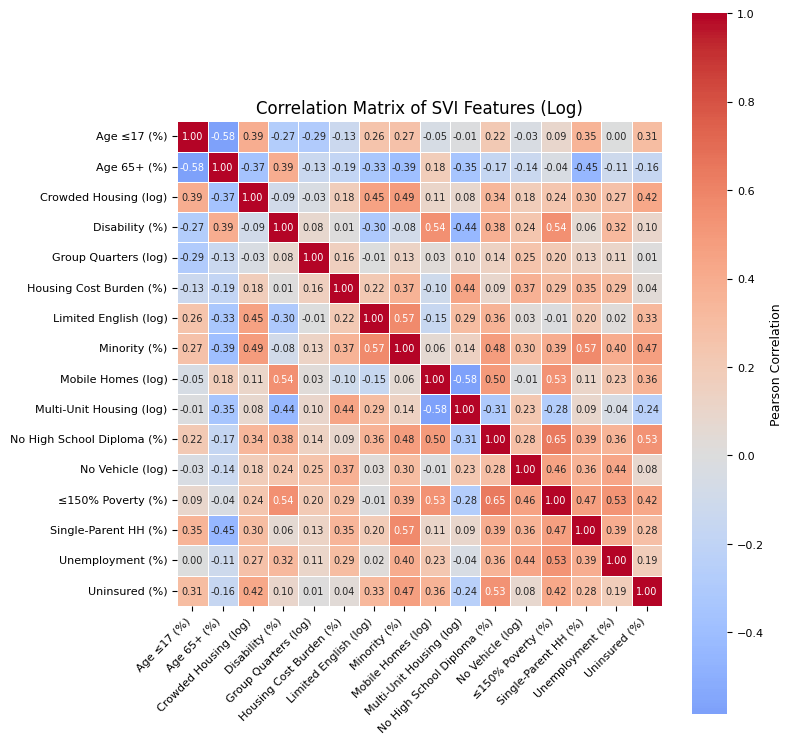

In [122]:
#| label: fig-svi-corr
#| fig-cap: "Pearson correlation matrix of the Social Vulnerability Index (SVI) feature set after selective log transformation. Several socioeconomic indicators—including poverty, unemployment, and lack of high school education—exhibit moderate to strong positive correlations, reflecting shared underlying economic vulnerability. Housing-related indicators such as crowding, multi-unit housing, and limited English proficiency also show notable associations with minority population measures. In contrast, age-based indicators (population under 17 and over 65) display weaker relationships with most socioeconomic variables, indicating distinct demographic patterns across counties."

# Compute correlation matrix
corr = X_log[cols_log].corr()

# Rename for readability in the heatmap
corr_plot = corr.rename(index=feature_titles_log, columns=feature_titles_log)

plt.figure(figsize=(8, 8))

sns.heatmap(
    corr_plot,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,        
    fmt=".2f",          
    annot_kws={"size":7},
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title("Correlation Matrix of SVI Features (Log)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Multicollinearity Assessment

To further evaluate redundancy among predictors, variance inflation factors (VIF) are computed for both the original and log-transformed feature sets. The distribution of VIF values across threshold categories is summarized in @tbl-svi-vif-thresholds, while detailed feature-level statistics are presented in @tbl-svi-vif.

The results indicate that a substantial portion of features exhibit moderate to high multicollinearity, particularly among variables representing related socioeconomic conditions. For example, disability, poverty, housing cost burden, and certain demographic indicators display elevated VIF values. This behavior is expected given that many SVI indicators capture interconnected aspects of socioeconomic vulnerability.

Log transformation reduces some collinearity effects but does not eliminate them entirely, reflecting the inherent conceptual overlap among several indicators.

In [123]:
#| label: tbl-svi-vif
#| tbl-cap: "Variance Inflation Factor (VIF) for SVI indicator variables before and after selective log transformation. Variables in the original feature set (X) and transformed feature set (X_log) are sorted independently in descending order of VIF. The results show that multicollinearity remains substantial across several socioeconomic and housing-related indicators, and in some cases increases after log transformation, reflecting the strong structural relationships inherent in the SVI variables."

# VIF for original features
vif_X = pd.DataFrame({
    "X_feature": X.columns,
    "VIF_X": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values("VIF_X", ascending=False).reset_index(drop=True)

# VIF for log-transformed features
vif_X_log = pd.DataFrame({
    "X_log_feature": X_log.columns,
    "VIF_X_log": [variance_inflation_factor(X_log.values, i) for i in range(X_log.shape[1])]
}).sort_values("VIF_X_log", ascending=False).reset_index(drop=True)

# Combine side-by-side
vif_table = pd.concat([vif_X, vif_X_log], axis=1)

# Display without index
display(vif_table.style.hide(axis="index"))

X_feature,VIF_X,X_log_feature,VIF_X_log
EP_DISABL,32.436276,EP_DISABL,32.992501
EP_POV150,29.560667,EP_NOVEH_LOG,32.855276
EP_HBURD,28.979922,EP_HBURD,32.521390
EP_AGE17,25.518015,EP_POV150,31.007330
EP_AGE65,20.663351,EP_AGE17,28.636644
EP_NOHSDP,19.290140,EP_AGE65,21.886795
EP_SNGPNT,13.942908,EP_MOBILE_LOG,19.774705
EP_UNEMP,8.644270,EP_NOHSDP,16.553763
EP_UNINSUR,8.013552,EP_SNGPNT,13.842576
EP_MINRTY,7.325821,EP_MUNIT_LOG,10.506437


In [124]:
#| label: tbl-svi-vif-thresholds
#| tbl-cap: "Counts and rates of SVI indicator variables falling within common VIF threshold ranges before and after selective log transformation, indicating that multicollinearity remains substantial and increases overall after transformation."

threshold_table = pd.DataFrame({
    "Threshold": [
        "VIF < 5 (Low)",
        "5 ≤ VIF < 10 (Moderate)",
        "VIF ≥ 10 (High)"
    ],
    "Count_X": [
        (vif_X["VIF_X"] < 5).sum(),
        ((vif_X["VIF_X"] >= 5) & (vif_X["VIF_X"] < 10)).sum(),
        (vif_X["VIF_X"] >= 10).sum()
    ],
    "Rate_X": [
        round((vif_X["VIF_X"] < 5).sum() / len(vif_X), 2),
        round(((vif_X["VIF_X"] >= 5) & (vif_X["VIF_X"] < 10)).sum() / len(vif_X), 2),
        round((vif_X["VIF_X"] >= 10).sum() / len(vif_X), 2)
    ],
    "Count_X_log": [
        (vif_X_log["VIF_X_log"] < 5).sum(),
        ((vif_X_log["VIF_X_log"] >= 5) & (vif_X_log["VIF_X_log"] < 10)).sum(),
        (vif_X_log["VIF_X_log"] >= 10).sum()
    ],
    "Rate_X_log": [
        round((vif_X_log["VIF_X_log"] < 5).sum() / len(vif_X_log), 2),
        round(((vif_X_log["VIF_X_log"] >= 5) & (vif_X_log["VIF_X_log"] < 10)).sum() / len(vif_X_log), 2),
        round((vif_X_log["VIF_X_log"] >= 10).sum() / len(vif_X_log), 2)
    ]
})

# Format rate columns to two decimals
threshold_table["Rate_X"] = threshold_table["Rate_X"].map("{:.2f}".format)
threshold_table["Rate_X_log"] = threshold_table["Rate_X_log"].map("{:.2f}".format)

display(threshold_table.style.hide(axis="index"))

Threshold,Count_X,Rate_X,Count_X_log,Rate_X_log
VIF < 5 (Low),4,0.25,0,0.00
5 ≤ VIF < 10 (Moderate),5,0.31,5,0.31
VIF ≥ 10 (High),7,0.44,11,0.69


### Cluster Analysis, PCA, and Latent Structure

To further understand the structure of the EP_* feature space, unsupervised clustering and dimensionality reduction are performed. These analyses help identify whether counties naturally group into similar vulnerability profiles and whether the high-dimensional feature matrix can be represented in a smaller number of latent components.

#### K-Means Cluster Diagnostics

To determine an appropriate number of clusters, K-means clustering is evaluated across multiple values of (k). The results are summarized numerically in @tbl-svi-kmeans-diagnostics and visually in @fig-svi-kmeans-diagnostics.

The inertia curve decreases monotonically as (k) increases, which is expected since additional clusters reduce within-cluster variance. However, the **largest reductions occur between (k=1) and (k=4)**, after which improvements become progressively smaller. The silhouette scores show their highest value at (k=2), indicating the strongest separation between two broad vulnerability regimes, but scores gradually decline as additional clusters are introduced.

The gap statistic and Calinski–Harabasz index suggest diminishing returns beyond approximately (k=4). Taken together, these diagnostics indicate that a **four-cluster solution provides a reasonable balance between cluster separation and interpretability**, capturing meaningful variation without excessive fragmentation.

In [135]:
#| label: tbl-svi-kmeans-diagnostics
#| tbl-cap: "K-means clustering diagnostics across candidate numbers of clusters (k = 1–10) computed using standardized log-transformed SVI indicators. The table reports inertia (within-cluster dispersion), silhouette score, Calinski–Harabasz index, and the gap statistic with its standard error (sk). Together these metrics help identify an appropriate number of clusters by evaluating cluster compactness, separation, and improvement relative to a reference distribution."

# Standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Set range for K
k_range = range(1, 11)

# Evaluate Kmeans metrics
metrics_df = evaluate_kmeans_k(
    X_scaled,
    k_range=k_range,
    random_state=42,
    n_init=20,
    n_refs_gap=20,
)

display(metrics_df.style.hide(axis="index"))

k,inertia,silhouette,calinski_harabasz,gap,sk
1,50304.000000,nan,nan,1.865095,0.005457
2,41269.949973,0.198499,687.789526,1.955778,0.005735
3,36686.643754,0.148047,582.938525,2.017746,0.004386
4,33671.782842,0.132713,517.002244,2.055092,0.002734
5,31839.106895,0.120809,455.110908,2.074823,0.005504
6,30413.918027,0.118514,410.437598,2.091467,0.004923
7,29147.545896,0.108393,379.493336,2.105053,0.003451
8,28034.962124,0.112214,355.860262,2.118440,0.004194
9,27156.078024,0.112367,334.036057,2.131382,0.005073
10,26332.372312,0.109271,317.003473,2.146262,0.004345


In [126]:
#| output: false

# Check for a recommended K by gap rule
k_gap = choose_k_gap_rule(metrics_df[["k", "gap", "sk"]])
print("Gap-statistic recommended k:", k_gap)

Gap-statistic recommended k: None


(<Figure size 600x400 with 4 Axes>,
 array([[<Axes: title={'center': 'KMeans Inertia (Elbow)'}, xlabel='k', ylabel='Inertia'>,
         <Axes: title={'center': 'Silhouette Score'}, xlabel='k', ylabel='Silhouette Score'>],
        [<Axes: title={'center': 'Calinski–Harabasz'}, xlabel='k', ylabel='CH Score'>,
         <Axes: title={'center': 'Gap Statistic'}, xlabel='k', ylabel='Gap Statistic'>]],
       dtype=object))

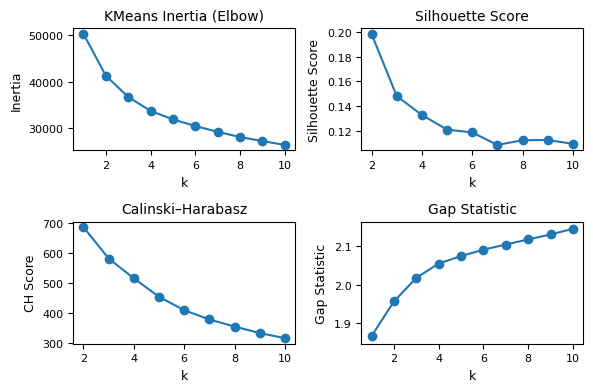

In [127]:
#| label: fig-svi-kmeans-diagnostics
#| fig-cap: "Clustering diagnostics for K-means across candidate numbers of clusters (k = 1–10) using standardized log-transformed SVI indicators. The elbow curve (inertia) measures within-cluster dispersion, the silhouette score evaluates cluster separation, the Calinski–Harabasz index assesses cluster compactness relative to between-cluster variance, and the gap statistic compares observed clustering structure to a reference null distribution. Together these metrics suggest diminishing returns beyond approximately k ≈ 3–4 clusters."

# Plot Kmean metrics
plot_k_diagnostics(metrics_df)

#### Cluster Visualization in PCA Space

To visualize the cluster structure, counties are projected into the first two principal components and colored according to cluster assignment. The resulting visualization is shown in @fig-svi-kmeans-pca-clusters.

The first two principal components explain approximately **28.2% and 19.5% of the variance**, respectively, providing a useful low-dimensional representation of the feature space. The clusters form partially overlapping but distinguishable regions within this projection, indicating that counties share broad vulnerability patterns while still exhibiting gradual transitions between profiles. The overlap between clusters reflects the continuous nature of socioeconomic vulnerability rather than sharply defined group boundaries.

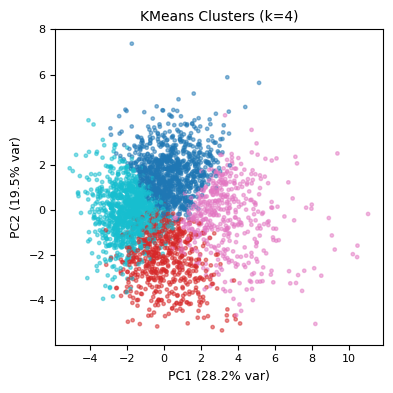

In [128]:
#| label: fig-svi-kmeans-pca-clusters
#| fig-cap: "Two-dimensional PCA projection of counties based on standardized log-transformed SVI indicators, colored by K-means cluster assignment (k = 4). Each point represents a county, while the axes correspond to the first two principal components explaining 29.3% and 20.5% of the total variance, respectively. The separation of colored groups indicates that the clusters capture meaningful structure in the multidimensional vulnerability feature space."

# Pick a K and fit
k_final = 4
km, labels = fit_kmeans(X_scaled, k=k_final, random_state=42, n_init=20)

# Project PCs
Z2, evr = pca_project(X_scaled, n_components=2)
plot_clusters_pca(Z2, labels, evr, title=f"KMeans Clusters (k={k_final})")

#### Cluster Feature Profiles

The mean feature values for each cluster are summarized in @tbl-svi-cluster-profiles and visualized as standardized feature profiles in @fig-svi-cluster-heatmap. These profiles illustrate how different clusters are characterized by distinct combinations of vulnerability indicators.

Some clusters exhibit **elevated socioeconomic stress indicators**, such as higher poverty, unemployment, and uninsured rates, while others are characterized by **housing-related vulnerabilities** such as crowded housing or limited transportation access. Certain clusters show relatively low levels across most indicators, representing counties with comparatively lower vulnerability levels.

The variation across clusters highlights the **multidimensional nature of vulnerability**, where different regions may experience vulnerability through different combinations of socioeconomic and demographic factors.

In [129]:
#| label: tbl-svi-cluster-profiles
#| tbl-cap: "Mean values of log-transformed SVI indicator variables for each K-means cluster (k = 4). Columns represent cluster centroids in feature space, while the spread column reports the difference between the maximum and minimum cluster mean for each indicator, highlighting the variables that most strongly differentiate vulnerability profiles across clusters."

cluster_profile = (
    pd.DataFrame(X_log, columns=X_log.columns)
    .assign(cluster=labels)
    .groupby("cluster")
    .mean()
)
cluster_table = cluster_profile.T
cluster_table["spread"] = cluster_table.max(axis=1) - cluster_table.min(axis=1)

display(cluster_table.sort_values("spread", ascending=False))


cluster,0,1,2,3,spread
EP_MINRTY,20.929538,32.772803,54.819915,12.310420,42.509495
EP_POV150,28.648615,20.347761,32.722458,17.976325,14.746132
EP_NOHSDP,14.180205,8.786235,18.986441,7.797898,11.188543
EP_UNINSUR,10.254872,7.730348,15.714831,7.158501,8.556330
EP_DISABL,20.473744,12.778109,15.982839,14.328702,7.695634
EP_HBURD,21.455795,25.984080,23.861229,19.069744,6.914336
EP_AGE65,21.791385,16.219237,16.052331,21.339214,5.739054
EP_AGE17,20.623077,21.755556,25.262076,21.657678,4.638999
EP_SNGPNT,5.518667,6.135323,8.767585,4.397623,4.369961
EP_UNEMP,5.773333,4.981426,6.733475,3.433272,3.300202


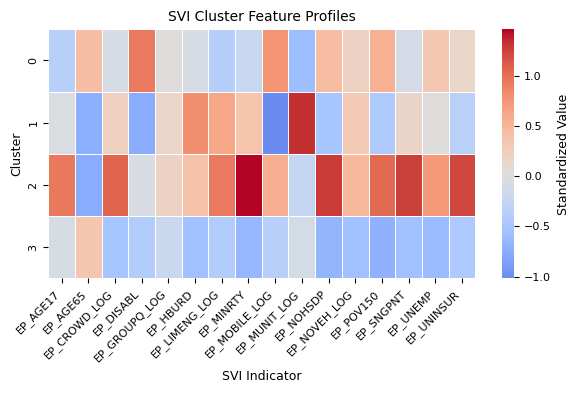

In [136]:
#| label: fig-svi-cluster-heatmap
#| fig-cap: "Heatmap of standardized cluster centroids for the K-means clustering solution (k = 4) based on log-transformed SVI indicators. Each row represents a cluster and each column corresponds to an SVI feature. Colors indicate the relative magnitude of each indicator compared to the overall mean after standardization, highlighting the vulnerability characteristics that distinguish the clusters."

cluster_profile_scaled = (
    pd.DataFrame(X_scaled, columns=X_log.columns)
    .assign(cluster=labels)
    .groupby("cluster")
    .mean()
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cluster_profile_scaled,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardized Value"}
)

plt.title("SVI Cluster Feature Profiles")
plt.xlabel("SVI Indicator")
plt.ylabel("Cluster")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

#### Geographic Distribution of Clusters

The spatial distribution of cluster assignments is shown for the contiguous United States (CONUS) in @fig-svi-cluster-map-conus and for Alaska and Hawaii (OCONUS) in @fig-svi-map-cluster-oconus.

The maps reveal clear **regional clustering patterns**, where neighboring counties frequently share similar vulnerability profiles. Certain clusters appear more frequently in parts of the Southeast, Southwest, and portions of the rural Midwest, while other clusters dominate in regions with lower overall vulnerability indicators. These spatial patterns suggest that vulnerability profiles are influenced not only by local socioeconomic conditions but also by broader regional characteristics.

The spatial coherence observed in the cluster maps provides further evidence that **vulnerability patterns are geographically structured rather than randomly distributed**, reinforcing the importance of incorporating spatial relationships in subsequent modeling approaches.

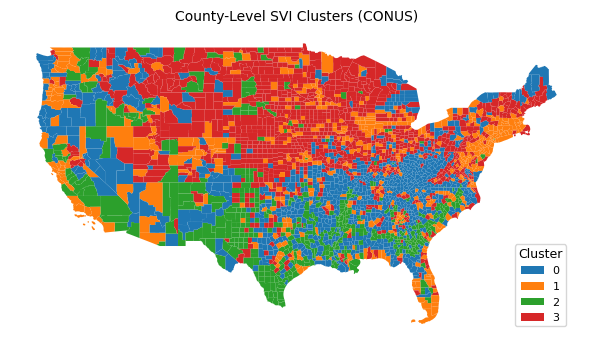

In [143]:
#| label: fig-svi-cluster-map-conus
#| fig-cap: "Geographic distribution of county-level vulnerability profiles across CONUS based on K-means clustering of standardized log-transformed SVI indicators. Each color represents a cluster of counties with similar socioeconomic, demographic, and housing characteristics. The spatial continuity of clusters suggests strong geographic structure in social vulnerability patterns."

geo_cluster = geo_df.copy()
geo_cluster["cluster"] = labels.astype(int)

# Remove Alaska, Hawaii, and territories
conus = geo_cluster[
    ~geo_cluster["FIPS"].str.startswith(("02", "15", "60", "66", "69", "72", "78"))
].copy()

# Match matplotlib default categorical colors
cluster_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
cluster_cmap = ListedColormap(cluster_colors)

fig, ax = plt.subplots(figsize=(6, 6))

conus.plot(
    column="cluster",
    cmap=cluster_cmap,
    categorical=True,
    linewidth=0.05,
    edgecolor="none",
    legend=False,   # turn off GeoPandas auto-legend
    ax=ax
)

# Manual legend so location is fully controllable
handles = [
    Patch(facecolor=cluster_colors[i], edgecolor="none", label=str(i))
    for i in sorted(conus["cluster"].unique())
]

ax.legend(
    handles=handles,
    title="Cluster",
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    frameon=True,
    borderaxespad=0.5
)

ax.set_title("County-Level SVI Clusters (CONUS)")
ax.axis("off")

plt.tight_layout()
plt.show()

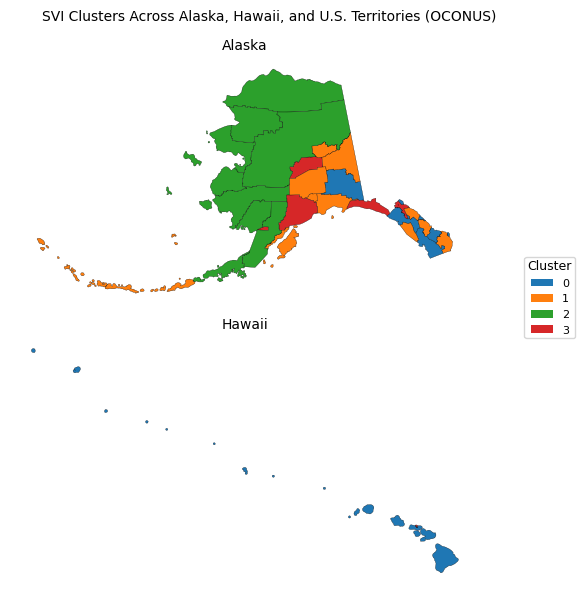

In [151]:
#| label: fig-svi-map-cluster-oconus
#| fig-cap: "County-level social vulnerability clusters for Alaska and Hawaii based on K-means clustering of standardized log-transformed SVI indicators. Colors represent distinct vulnerability profiles derived from the clustering analysis. Cluster assignments are shown for Alaska and Hawaii. No SVI feature data were available for the U.S. territories."

# Copy and attach cluster labels
geo_cluster = geo_df.copy()
geo_cluster["cluster"] = labels.astype(int)

# Define Alaska, Hawaii, and territories
ak = geo_cluster[geo_cluster["FIPS"].str.startswith("02")]
hi = geo_cluster[geo_cluster["FIPS"].str.startswith("15")]
territories = geo_cluster[geo_cluster["FIPS"].str.startswith(("60", "66", "69", "72", "78"))]

# Reproject for cleaner OCONUS display
ak_proj = ak.to_crs("EPSG:3338")
hi_proj = hi.to_crs("EPSG:3759")
territories_proj = territories.to_crs("EPSG:3857")

# Match map colors to cluster profile colors
cluster_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
cluster_cmap = ListedColormap(cluster_colors)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

fig.suptitle(
    "SVI Clusters Across Alaska, Hawaii, and U.S. Territories (OCONUS)",
    fontsize=10
)

oconus_datasets = [
    (ak_proj, "Alaska"),
    (hi_proj, "Hawaii")
]

for ax, (data, title) in zip(axes, oconus_datasets):

    if data.empty:
        ax.text(0.5, 0.5, f"No data for {title}", ha="center", va="center")
        ax.set_title(title)
        ax.axis("off")
        continue

    data.plot(
        column="cluster",
        cmap=cluster_cmap,
        categorical=True,
        linewidth=0.2,
        edgecolor="black",
        legend=False,  # disable automatic legend
        ax=ax
    )

    ax.set_title(title)
    ax.axis("off")

# Create single manual legend
handles = [
    Patch(facecolor=cluster_colors[i], edgecolor="none", label=str(i))
    for i in sorted(geo_cluster["cluster"].unique())
]

fig.legend(
    handles=handles,
    title="Cluster",
    loc="center right",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

#### Principal Component Analysis

Principal Component Analysis (PCA) is applied to examine the intrinsic dimensionality of the EP_* feature matrix. The cumulative explained variance across principal components is shown in @fig-svi-pca-cumvar.

The first few principal components capture a substantial portion of the variance in the dataset. Approximately **80% of the variance is explained by around seven to eight components**, while roughly **90% of the variance is captured by about ten components**. This indicates that although the dataset contains sixteen original features, much of the variability in the vulnerability indicators can be summarized by a smaller number of latent dimensions.

These latent components likely represent broader socioeconomic patterns that combine multiple related indicators, such as economic hardship, demographic dependency, or housing instability.

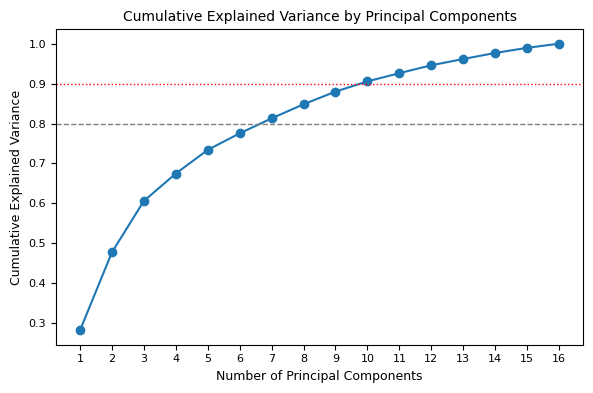

In [133]:
#| label: fig-svi-pca-cumvar
#| fig-cap: "Cumulative explained variance of principal components derived from standardized log-transformed SVI indicators. The first few components capture a substantial portion of total variance, with approximately 80% explained by the first six components and about 90% explained by the first nine components. Horizontal reference lines indicate common variance retention thresholds used to assess the dimensionality required to summarize county-level vulnerability patterns."

# Fit PCA on X_scaled
pca_full = PCA()
pca_full.fit(X_scaled)

# Compute explained variance
explained_var = pca_full.explained_variance_ratio_
cum_explained_var = explained_var.cumsum()
pcs = np.arange(1, len(explained_var) + 1)

plt.figure(figsize=(6, 4))
plt.plot(pcs, cum_explained_var, marker="o")
plt.axhline(0.80, linestyle="--", linewidth=1, color="gray")
plt.axhline(0.90, linestyle=":", linewidth=1, color="red")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Principal Components")
plt.xticks(pcs)

plt.tight_layout()
plt.show()

### Implications for Modeling

The exploratory analysis of the EP_* feature matrix highlights several important characteristics relevant for model development. First, many vulnerability indicators exhibit **right-skewed and heavy-tailed distributions**, particularly for housing and access-related variables such as crowded housing, limited English proficiency, and lack of vehicle access. Selective log transformations help reduce skewness and stabilize feature variance, producing more numerically balanced inputs for model training. Second, correlation and variance inflation factor analyses reveal **moderate to high multicollinearity among several socioeconomic indicators**, reflecting the interconnected nature of economic hardship, housing instability, and demographic vulnerability. Rather than aggressively removing correlated variables, the full feature set is retained because neural network models are generally robust to correlated inputs and can learn nonlinear combinations of predictors.

Unsupervised clustering and principal component analysis further demonstrate that counties exhibit **structured vulnerability profiles and meaningful latent dimensions within the feature space**. The clustering results suggest that counties can be grouped into a small number of broad vulnerability regimes, while PCA indicates that much of the variation in the sixteen EP_* indicators can be captured by a smaller set of underlying components. The geographic coherence of cluster assignments also suggests that vulnerability patterns exhibit **strong spatial organization across neighboring counties**. Together, these findings support the modeling strategy adopted in this study: using the transformed EP_* indicators as predictors while allowing machine learning models—particularly graph-based approaches—to capture both nonlinear feature interactions and spatial dependencies across counties.

In [152]:
# Save artifacts
geo_df.to_file(
    "../data/processed/svi_counties.gpkg",
    layer="counties",
    driver="GPKG"
)
X.to_csv("../data/processed/X.csv", index=False)
X_log.to_csv("../data/processed/X_log.csv", index=False)
y.to_csv("../data/processed/y.csv", index=False)

# Save as JSON
with open("../data/processed/feature_titles.json", "w") as f:
    json.dump(feature_titles_log, f, indent=2)